In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats
import itertools 

In [19]:
results_csv = pd.read_csv("../results/program_recognition_results.csv")
results_csv = results_csv.drop("Unnamed: 0", axis=1)
results_csv

,key,path,found_perm,true_perm,correct,overlap
0,a,/Users/jdreiling/Desktop/puck/puck//images/cus...,afd,afd,True,3
1,a,/Users/jdreiling/Desktop/puck/puck//images/cus...,afd,afd,True,3
2,a,/Users/jdreiling/Desktop/puck/puck//images/cus...,abd,afd,False,2
3,a,/Users/jdreiling/Desktop/puck/puck//images/cus...,efd,afd,False,2
4,a,/Users/jdreiling/Desktop/puck/puck//images/cus...,afd,afd,True,3
...,...,...,...,...,...,...
235,d,/Users/jdreiling/Desktop/puck/puck//images/cus...,fff,fff,True,3
236,d,/Users/jdreiling/Desktop/puck/puck//images/cus...,fff,fff,True,3
237,d,/Users/jdreiling/Desktop/puck/puck//images/cus...,fff,fff,True,3
238,d,/Users/jdreiling/Desktop/puck/puck//images/cus...,fff,fff,True,3


Text(0.5, 1.0, 'Count of Overlaps per Permutation Key')

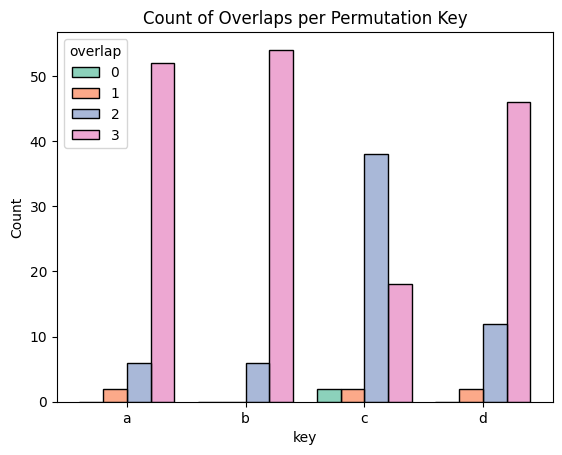

In [20]:
sns.histplot(data= results_csv, x = "key",hue="overlap",multiple="dodge", shrink=.8,palette= sns.color_palette("Set2")[:4])
plt.title("Count of Overlaps per Permutation Key")

In [21]:
results_csv_c = results_csv[results_csv["key"] == "c"]
print(results_csv_c["true_perm"].values[0])
results_csv_c["found_perm"].value_counts()

ebg


found_perm
efg    38
ebg    18
gce     2
efe     1
ece     1
Name: count, dtype: int64

In [22]:
results_csv_d = results_csv[results_csv["key"] == "d"]
print(results_csv_d["true_perm"].values[0])
results_csv_d["found_perm"].value_counts()

fff


found_perm
fff    46
fbf     4
bff     3
bbf     2
ffa     2
ffb     1
faf     1
aff     1
Name: count, dtype: int64

"#FE00FF",b
"#DB4F89",f

It frequently seems to get b and f confused.

In [23]:
results_csv_d = results_csv[results_csv["key"] == "d"]
print(results_csv_d["true_perm"].values[0])
results_csv_d["found_perm"].value_counts()

fff


found_perm
fff    46
fbf     4
bff     3
bbf     2
ffa     2
ffb     1
faf     1
aff     1
Name: count, dtype: int64

In [24]:
acc_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_csv[results_csv["key"] == k]
    accuracy = round((sum(key_selection["correct"])/len(key_selection["correct"])),3)
    acc_dict.update({k: accuracy})

acc_dict

{'a': 0.867, 'b': 0.9, 'c': 0.3, 'd': 0.767}

In [25]:
close_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_csv[results_csv["key"] == k]
    close = key_selection[(key_selection["overlap"]).astype(int) >= 2]
    close_acc = round((len(close)/len(key_selection["overlap"])),3)
    close_dict.update({k: close_acc})

close_dict

{'a': 0.967, 'b': 1.0, 'c': 0.933, 'd': 0.967}

In [26]:
def path_cutter(df):
    df["path2"] = df["path"].str.slice(50,len(df["path"]))
    df[['loc','height', 'perm', 'path']] = df.path2.str.split("/",expand=True)
    df = df.drop(["path2"], axis=1)

In [27]:
path_cutter(results_csv)
results_csv = results_csv.drop(["path2"], axis=1)

In [28]:
results_csv_c = results_csv[results_csv["key"] == "c"]
results_csv_c

,key,path,found_perm,true_perm,correct,overlap,loc,height,perm
120,c,custom_michaels_high_C_1.jpg,efg,ebg,False,2,michaels,high,C
121,c,custom_michaels_high_C_0.jpg,efg,ebg,False,2,michaels,high,C
122,c,custom_michaels_high_C_2.jpg,efg,ebg,False,2,michaels,high,C
123,c,custom_michaels_high_C_3.jpg,efg,ebg,False,2,michaels,high,C
124,c,custom_michaels_high_C_4.jpg,efg,ebg,False,2,michaels,high,C
125,c,custom_michaels_short_C_1.jpg,efg,ebg,False,2,michaels,short,C
126,c,custom_michaels_short_C_0.jpg,efg,ebg,False,2,michaels,short,C
127,c,custom_michaels_short_C_2.jpg,efg,ebg,False,2,michaels,short,C
128,c,custom_michaels_short_C_3.jpg,ebg,ebg,True,3,michaels,short,C
129,c,custom_michaels_short_C_4.jpg,efe,ebg,False,1,michaels,short,C


In [29]:
def pivot_creator(df:pd.DataFrame):
    entries = []
    for height, loc, in itertools.product(df["height"].unique(), df["loc"].unique()):
        selection = df[(df["height"] == height) & (df["loc"] == loc)]
        overlap_avg = stats.mean(selection["overlap"])
        entries.append({"height": height, "loc": loc, "overlap_avg": overlap_avg})
    return pd.DataFrame(entries, columns=["height", "loc", "overlap_avg"])

<Axes: xlabel='height', ylabel='loc'>

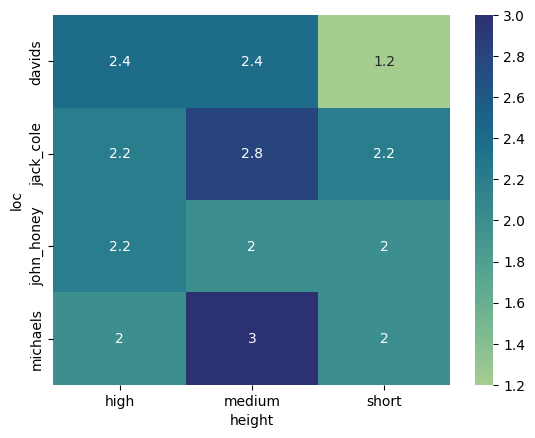

In [30]:
pivot_df = pivot_creator(results_csv_c)
results_c_pivot = (pivot_df.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_c_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))

In [31]:
results_csv_c_low= results_csv_c[results_csv_c["height"] == "short"]
results_csv_c_low["found_perm"].value_counts()

found_perm
efg    13
ebg     3
gce     2
efe     1
ece     1
Name: count, dtype: int64

In [32]:
results_dark_csv = pd.read_csv("../results/program_recognition_results_dark.csv")
results_dark_csv = results_dark_csv.drop("Unnamed: 0", axis=1)
results_dark_csv

,key,path,found_perm,true_perm,correct,overlap
0,a,/Users/jdreiling/Desktop/puck/puck//images/dar...,afd,afd,True,3
1,a,/Users/jdreiling/Desktop/puck/puck//images/dar...,ahd,afd,False,2
2,a,/Users/jdreiling/Desktop/puck/puck//images/dar...,ahd,afd,False,2
3,a,/Users/jdreiling/Desktop/puck/puck//images/dar...,afd,afd,True,3
4,a,/Users/jdreiling/Desktop/puck/puck//images/dar...,afd,afd,True,3
...,...,...,...,...,...,...
235,d,/Users/jdreiling/Desktop/puck/puck//images/dar...,fhh,fff,False,1
236,d,/Users/jdreiling/Desktop/puck/puck//images/dar...,fff,fff,True,3
237,d,/Users/jdreiling/Desktop/puck/puck//images/dar...,hhh,fff,False,0
238,d,/Users/jdreiling/Desktop/puck/puck//images/dar...,fhf,fff,False,2


Text(0.5, 1.0, 'Count of Overlaps per Permutation Key')

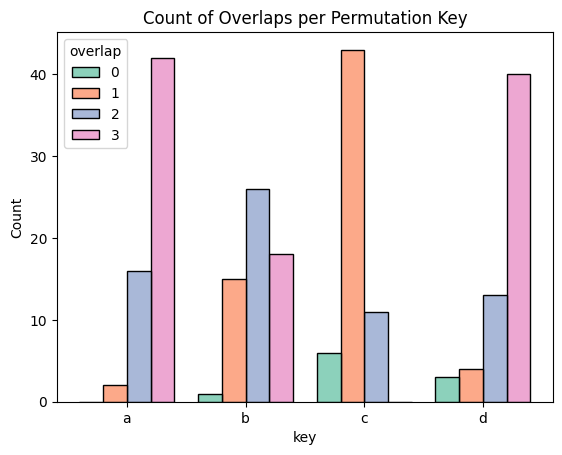

In [34]:
sns.histplot(data= results_dark_csv, x = "key",hue="overlap",multiple="dodge", shrink=.8,palette= sns.color_palette("Set2")[:4])
plt.title("Count of Overlaps per Permutation Key")

In [35]:
path_cutter(results_dark_csv)
results_dark_csv = results_dark_csv.drop(["path2"], axis=1)

In [36]:
results_dark_csv

,key,path,found_perm,true_perm,correct,overlap,loc,height,perm
0,a,dark_michaels_high_A_1.jpg,afd,afd,True,3,chaels,high,A
1,a,dark_michaels_high_A_0.jpg,ahd,afd,False,2,chaels,high,A
2,a,dark_michaels_high_A_2.jpg,ahd,afd,False,2,chaels,high,A
3,a,dark_michaels_high_A_3.jpg,afd,afd,True,3,chaels,high,A
4,a,dark_michaels_high_A_4.jpg,afd,afd,True,3,chaels,high,A
...,...,...,...,...,...,...,...,...,...
235,d,dark_jack_cole_medium_D_1.jpg,fhh,fff,False,1,ck_cole,medium,D
236,d,dark_jack_cole_medium_D_0.jpg,fff,fff,True,3,ck_cole,medium,D
237,d,dark_jack_cole_medium_D_2.jpg,hhh,fff,False,0,ck_cole,medium,D
238,d,dark_jack_cole_medium_D_3.jpg,fhf,fff,False,2,ck_cole,medium,D


In [45]:
results_dark_csv_c = results_dark_csv[results_dark_csv["key"] == "c"]
results_dark_csv_b = results_dark_csv[results_dark_csv["key"] == "b"]
results_dark_csv_d = results_dark_csv[results_dark_csv["key"] == "d"]

In [39]:
print(results_dark_csv_c["true_perm"].values[0])
results_dark_csv_c["found_perm"].value_counts()

ebg


found_perm
gfg    18
ghg    18
efg    11
efe     4
ggh     4
bfg     3
ggf     2
Name: count, dtype: int64

In [41]:
print(results_dark_csv_b["true_perm"].values[0])
results_dark_csv_b["found_perm"].value_counts()

ahc


found_perm
adc    26
ahc    18
adg    14
gdg     1
gdc     1
Name: count, dtype: int64

In [46]:
print(results_dark_csv_d["true_perm"].values[0])
results_dark_csv_d["found_perm"].value_counts()

fff


found_perm
fff    40
ffh    10
fhf     3
hhh     3
fhh     3
hfh     1
Name: count, dtype: int64

In [ ]:
acc_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_dark_csv[results_dark_csv["key"] == k]
    accuracy = round((sum(key_selection["correct"])/len(key_selection["correct"])),3)
    acc_dict.update({k: accuracy})

acc_dict

{'a': 0.7, 'b': 0.3, 'c': 0.0, 'd': 0.667}

In [43]:
close_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_dark_csv[results_dark_csv["key"] == k]
    close = key_selection[(key_selection["overlap"]).astype(int) >= 2]
    close_acc = round((len(close)/len(key_selection["overlap"])),3)
    close_dict.update({k: close_acc})

close_dict

{'a': 0.967, 'b': 0.733, 'c': 0.183, 'd': 0.883}

<Axes: xlabel='height', ylabel='loc'>

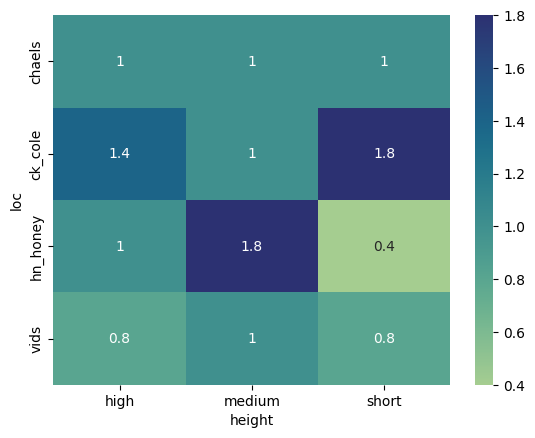

In [38]:
pivot_df_dark = pivot_creator(results_dark_csv_c)
results_dark_c_pivot = (pivot_df_dark.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_dark_c_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))

<Axes: xlabel='height', ylabel='loc'>

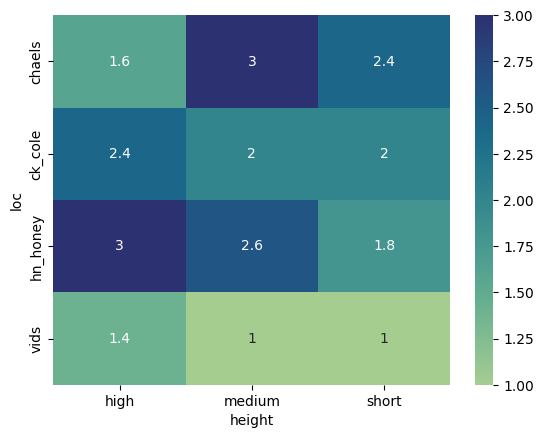

In [44]:
pivot_df_dark_b = pivot_creator(results_dark_csv_b)
results_dark_b_pivot = (pivot_df_dark_b.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_dark_b_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))